# 4 · From tracking to welfare — feeding, drinking, nesting

Now we turn positions and postures into the numbers a farmer actually cares about. We monitor three behaviours:

- **Feeding** — the bird is at the feeder.
- **Drinking** — the bird is at the waterer.
- **Laying / nesting** — the bird stays put in one spot for a long time.

Small changes in these routines often show up *before* a bird looks visibly sick, which is exactly what makes continuous monitoring valuable. We reuse the per-frame pen state from the tracker and apply simple, transparent rules.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Locate the repo root (folder holding pen_config.json) and make src/ + scripts/ importable.
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "pen_config.json").exists():
        break
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

import cv2, json
import numpy as np
import matplotlib.pyplot as plt

DEMO = ROOT / "output" / "demo"
DEMO.mkdir(parents=True, exist_ok=True)

SEG_MODEL  = "models/poultry-seg-yolo12s-v2.pt"
POSE_MODEL = "models/hen_pose_yolo12s_aug_v6.pt"   # the freshly retrained pose model
STEM = "20260605_141702"                            # a daytime synchronized clip
CAM0 = ROOT / "dataset/treatment1/cam0" / f"{STEM}.mp4"   # top-down
CAM1 = ROOT / "dataset/treatment1/cam1" / f"{STEM}.mp4"   # lateral

def show(img_bgr, title="", w=11):
    """Show a BGR image inline."""
    h, wd = img_bgr.shape[:2]
    plt.figure(figsize=(w, w * h / wd))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.axis("off")
    if title: plt.title(title, fontsize=13)
    plt.show()

def grab(video, idx=300):
    """Read one frame from a video."""
    cap = cv2.VideoCapture(str(video)); cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read(); cap.release()
    if not ok: raise RuntimeError(f"could not read frame {idx} of {video}")
    return fr


In [2]:
import pandas as pd
import track_pen
cfg = json.load(open(ROOT / "pen_config.json"))
csv_out = DEMO / "pen_state_behaviour.csv"
# a slightly longer clip so dwell-based nesting has time to show
track_pen.run(cam0_path=CAM0, cam1_path=CAM1, model_path=SEG_MODEL, cfg=cfg,
              conf=0.35, iou=0.5, margin_m=0.15, show=False,
              csv_path=csv_out, walls=False, save_video=None, max_frames=200)
df = pd.read_csv(csv_out)
df = df[df["visible"] == True] if df["visible"].dtype == bool else df[df["visible"].astype(str).isin(["True","1"])]
print(df.head()); print("rows:", len(df), "colours:", sorted(df.color.unique()))

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


Model: models/poultry-seg-yolo12s-v2.pt
Cam0 : C:\dev\poultry-vision\dataset\treatment1\cam0\20260605_141702.mp4
Cam1 : C:\dev\poultry-vision\dataset\treatment1\cam1\20260605_141702.mp4
Controls: [space] pause  [q] quit


f=    0  visible=0/5  missing=['green', 'black', 'red', 'blue', 'yellow']  feeder=...  waterer=...


f=   50  visible=3/5  missing=['green', 'black']  feeder=ok  waterer=...


f=  100  visible=3/5  missing=['green', 'black']  feeder=ok  waterer=...


f=  150  visible=3/5  missing=['green', 'black']  feeder=ok  waterer=...


Reached max-frames=200.
CSV written -> C:\dev\poultry-vision\output\demo\pen_state_behaviour.csv
    frame  timestamp  color  visible  floor_x  floor_y     views
6       1  6646.0862  black        1   0.6327   2.2565       top
8       1  6646.0862   blue        1   0.6701   0.4884       top
11      2  6646.1264  black        1   0.6327   2.2558       top
12      2  6646.1264    red        1   0.6267   2.2248      side
13      2  6646.1264   blue        1   0.5262   0.6256  side+top
rows: 599 colours: ['black', 'blue', 'red', 'yellow']


### Turn positions into behaviours
Feeding / drinking are a distance check against the feeder and waterer zones; nesting is a bird staying within a small radius for many frames.

In [3]:
res = json.load(open(ROOT / "config/resources_config.json"))
def near(row, z, r_extra=0.0):
    return (row.floor_x - z["x"])**2 + (row.floor_y - z["y"])**2 <= (z["r"] + r_extra)**2

def label(row):
    if "feeder"  in res and near(row, res["feeder"]):  return "feeding"
    if "waterer" in res and near(row, res["waterer"]): return "drinking"
    return "present"
df["behaviour"] = df.apply(label, axis=1)

# nesting: a colour that barely moves for a sustained run of frames
LAY_RADIUS, LAY_MIN_FRAMES = 0.15, 40
for c, g in df.groupby("color"):
    g = g.sort_values("frame")
    still = ((g.floor_x.diff().abs() < LAY_RADIUS) & (g.floor_y.diff().abs() < LAY_RADIUS))
    run = 0
    for i, s in zip(g.index, still):
        run = run + 1 if s else 0
        if run >= LAY_MIN_FRAMES and df.at[i, "behaviour"] == "present":
            df.at[i, "behaviour"] = "laying"
print(df.behaviour.value_counts())

behaviour
laying     471
present    128
Name: count, dtype: int64


### Per-hen behaviour budget
How each identified bird spent the clip.

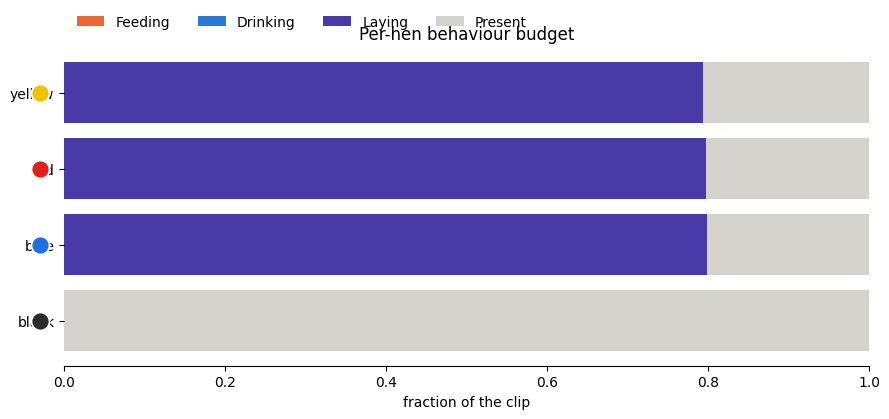

In [4]:
BEH = ["feeding","drinking","laying","present"]
COL = {"feeding":"#eb6834","drinking":"#2a78d6","laying":"#4a3aa7","present":"#d3d2cc"}
PAINT = {"yellow":"#f2c200","red":"#e0201b","blue":"#1f6fe0","green":"#0a9a2e","black":"#2b2b2b"}
summary = (df.groupby(["color","behaviour"]).size().unstack(fill_value=0)
             .reindex(columns=BEH, fill_value=0))
frac = summary.div(summary.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 0.7*len(frac)+1.5))
left = np.zeros(len(frac))
for b in BEH:
    ax.barh(frac.index, frac[b], left=left, color=COL[b], label=b.capitalize())
    left += frac[b].values
for i, c in enumerate(frac.index):
    ax.plot(-0.03, i, "o", ms=13, mfc=PAINT.get(c,"#888"), mec="white", mew=1.3, clip_on=False)
ax.set_xlim(0,1); ax.set_xlabel("fraction of the clip"); ax.set_title("Per-hen behaviour budget")
ax.legend(ncol=4, frameon=False, bbox_to_anchor=(0,1.02), loc="lower left")
for s in ("top","right","left"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(DEMO / "behaviour_budget.png", dpi=150); plt.show()

### The bigger picture
Run this across days and you get each bird's daily feeding, drinking, and nesting budget — an objective, continuous welfare record that a person watching by eye simply can't produce at scale. That's the whole point of the system.

Saved to `output/demo/behaviour_budget.png`.